<a href="https://colab.research.google.com/github/nraidina/LabML1_NurAidina_22005974/blob/main/Lab1_Car_Evaluation_22005974.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Car Evaluation

Nur Aidina binti Mohd Nasir || 22005974 || Lab Group 2

In [19]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# Load dataset

import pandas as pd

url = "https://raw.githubusercontent.com/nraidina/LabML1_NurAidina_22005974/main/car_evaluation.csv"

columns = [
    "Buying",
    "Maintenance",
    "Doors",
    "Persons",
    "Lug_Boot",
    "Safety",
    "Class"
]

df = pd.read_csv(url, names=columns)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1728, 7)


,Buying,Maintenance,Doors,Persons,Lug_Boot,Safety,Class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [21]:
# INITIAL INSPECTION

print("FIRST 5 RECORDS")
display(df.head())

print("\nDATASET INFO")
print(df.info())

print("\nSTATISTICAL SUMMARY")
display(df.describe(include='all'))

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATE RECORDS")
print(df.duplicated().sum())

FIRST 5 RECORDS


,Buying,Maintenance,Doors,Persons,Lug_Boot,Safety,Class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc



DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Buying       1728 non-null   object
 1   Maintenance  1728 non-null   object
 2   Doors        1728 non-null   object
 3   Persons      1728 non-null   object
 4   Lug_Boot     1728 non-null   object
 5   Safety       1728 non-null   object
 6   Class        1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB
None

STATISTICAL SUMMARY


,Buying,Maintenance,Doors,Persons,Lug_Boot,Safety,Class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210



MISSING VALUES
Buying         0
Maintenance    0
Doors          0
Persons        0
Lug_Boot       0
Safety         0
Class          0
dtype: int64

DUPLICATE RECORDS
0


In [22]:
# DATA CLEANING

# Remove duplicates

df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))

# Check missing values again
print("\nMissing Values")
print(df.isnull().sum())

Rows after removing duplicates: 1728

Missing Values
Buying         0
Maintenance    0
Doors          0
Persons        0
Lug_Boot       0
Safety         0
Class          0
dtype: int64


In [23]:
# DATA TYPE CONVERSION

buying_map = {
    'low':1,
    'med':2,
    'high':3,
    'vhigh':4
}

maintenance_map = {
    'low':1,
    'med':2,
    'high':3,
    'vhigh':4
}

safety_map = {
    'low':1,
    'med':2,
    'high':3
}

class_map = {
    'unacc':0,
    'acc':1,
    'good':2,
    'vgood':3
}

df['Buying_Num'] = df['Buying'].map(buying_map)
df['Maint_Num'] = df['Maintenance'].map(maintenance_map)
df['Safety_Num'] = df['Safety'].map(safety_map)
df['Class_Encoded'] = df['Class'].map(class_map)

display(df.head())

,Buying,Maintenance,Doors,Persons,Lug_Boot,Safety,Class,Buying_Num,Maint_Num,Safety_Num,Class_Encoded
0,vhigh,vhigh,2,2,small,low,unacc,4,4,1,0
1,vhigh,vhigh,2,2,small,med,unacc,4,4,2,0
2,vhigh,vhigh,2,2,small,high,unacc,4,4,3,0
3,vhigh,vhigh,2,2,med,low,unacc,4,4,1,0
4,vhigh,vhigh,2,2,med,med,unacc,4,4,2,0


In [24]:
# FILTERING

print("Cars with LOW buying price")

low_buying = df[df['Buying'] == 'low']

display(low_buying.head())

print("Total:", low_buying.shape[0])

Cars with LOW buying price


,Buying,Maintenance,Doors,Persons,Lug_Boot,Safety,Class,Buying_Num,Maint_Num,Safety_Num,Class_Encoded
1296,low,vhigh,2,2,small,low,unacc,1,4,1,0
1297,low,vhigh,2,2,small,med,unacc,1,4,2,0
1298,low,vhigh,2,2,small,high,unacc,1,4,3,0
1299,low,vhigh,2,2,med,low,unacc,1,4,1,0
1300,low,vhigh,2,2,med,med,unacc,1,4,2,0


Total: 432


In [25]:
# FEATURE CREATION

# Feature 1
df['Overall_Cost_Index'] = (
    df['Buying_Num'] +
    df['Maint_Num']
)

# Feature 2
df['Car_Score'] = (
    df['Buying_Num'] *
    df['Safety_Num']
)

display(df.head())

,Buying,Maintenance,Doors,Persons,Lug_Boot,Safety,Class,Buying_Num,Maint_Num,Safety_Num,Class_Encoded,Overall_Cost_Index,Car_Score
0,vhigh,vhigh,2,2,small,low,unacc,4,4,1,0,8,4
1,vhigh,vhigh,2,2,small,med,unacc,4,4,2,0,8,8
2,vhigh,vhigh,2,2,small,high,unacc,4,4,3,0,8,12
3,vhigh,vhigh,2,2,med,low,unacc,4,4,1,0,8,4
4,vhigh,vhigh,2,2,med,med,unacc,4,4,2,0,8,8


In [26]:
# COLUMN OPERATIONS

subset = df[['Buying','Maintenance','Safety','Class']]

display(subset.head())

,Buying,Maintenance,Safety,Class
0,vhigh,vhigh,low,unacc
1,vhigh,vhigh,med,unacc
2,vhigh,vhigh,high,unacc
3,vhigh,vhigh,low,unacc
4,vhigh,vhigh,med,unacc


In [27]:
# SORTING

sorted_df = df.sort_values(
    by='Overall_Cost_Index',
    ascending=False
)

display(sorted_df.head(10))

,Buying,Maintenance,Doors,Persons,Lug_Boot,Safety,Class,Buying_Num,Maint_Num,Safety_Num,Class_Encoded,Overall_Cost_Index,Car_Score
24,vhigh,vhigh,2,more,big,low,unacc,4,4,1,0,8,4
15,vhigh,vhigh,2,4,big,low,unacc,4,4,1,0,8,4
25,vhigh,vhigh,2,more,big,med,unacc,4,4,2,0,8,8
1,vhigh,vhigh,2,2,small,med,unacc,4,4,2,0,8,8
2,vhigh,vhigh,2,2,small,high,unacc,4,4,3,0,8,12
3,vhigh,vhigh,2,2,med,low,unacc,4,4,1,0,8,4
4,vhigh,vhigh,2,2,med,med,unacc,4,4,2,0,8,8
5,vhigh,vhigh,2,2,med,high,unacc,4,4,3,0,8,12
6,vhigh,vhigh,2,2,big,low,unacc,4,4,1,0,8,4
7,vhigh,vhigh,2,2,big,med,unacc,4,4,2,0,8,8


In [28]:
# TRANSFORMATION USING map()

df['Safety_Level'] = df['Safety'].map({
    'low':'Poor',
    'med':'Average',
    'high':'Good'
})

display(df[['Safety','Safety_Level']].head())

,Safety,Safety_Level
0,low,Poor
1,med,Average
2,high,Good
3,low,Poor
4,med,Average


In [29]:
# TRANSFORMATION USING apply()

df['High_Safety'] = df['Safety_Num'].apply(
    lambda x: "Yes" if x == 3 else "No"
)

display(df[['Safety','High_Safety']].head())

,Safety,High_Safety
0,low,No
1,med,No
2,high,Yes
3,low,No
4,med,No


In [30]:
# TRANSFORMATION USING applymap()

sample = df[['Buying_Num','Maint_Num']]

sample_scaled = sample.applymap(lambda x: x * 10)

display(sample_scaled.head())

/tmp/ipykernel_3820/561163528.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sample_scaled = sample.applymap(lambda x: x * 10)


,Buying_Num,Maint_Num
0,40,40
1,40,40
2,40,40
3,40,40
4,40,40


In [31]:
# LABEL ENCODING

display(df[['Class','Class_Encoded']].head())

,Class,Class_Encoded
0,unacc,0
1,unacc,0
2,unacc,0
3,unacc,0
4,unacc,0


In [32]:
# ONE-HOT ENCODING

one_hot_df = pd.get_dummies(
    df,
    columns=['Safety']
)

display(one_hot_df.head())

,Buying,Maintenance,Doors,Persons,Lug_Boot,Class,Buying_Num,Maint_Num,Safety_Num,Class_Encoded,Overall_Cost_Index,Car_Score,Safety_Level,High_Safety,Safety_high,Safety_low,Safety_med
0,vhigh,vhigh,2,2,small,unacc,4,4,1,0,8,4,Poor,No,False,True,False
1,vhigh,vhigh,2,2,small,unacc,4,4,2,0,8,8,Average,No,False,False,True
2,vhigh,vhigh,2,2,small,unacc,4,4,3,0,8,12,Good,Yes,True,False,False
3,vhigh,vhigh,2,2,med,unacc,4,4,1,0,8,4,Poor,No,False,True,False
4,vhigh,vhigh,2,2,med,unacc,4,4,2,0,8,8,Average,No,False,False,True


In [33]:
# GROUPING & AGGREGATION

print("COUNT OF CARS BY CLASS")

display(
    df.groupby('Class').size()
)

COUNT OF CARS BY CLASS


,0
Class,
acc,384
good,69
unacc,1210
vgood,65


In [34]:
# AVERAGE BUYING SCORE BY CLASS

display(
    df.groupby('Class')['Buying_Num'].mean()
)

,Buying_Num
Class,
acc,2.424479
good,1.333333
unacc,2.649587
vgood,1.400000


In [35]:
# MULTIPLE AGGREGATIONS

agg_result = df.groupby('Class').agg({
    'Buying_Num':['mean','max','min'],
    'Maint_Num':['mean','max'],
    'Overall_Cost_Index':['mean','count']
})

display(agg_result)

Buying_Num         Maint_Num     Overall_Cost_Index      
            mean max min      mean max               mean count
Class                                                          
acc     2.424479   4   1  2.408854   4           4.833333   384
good    1.333333   2   1  1.333333   2           2.666667    69
unacc   2.649587   4   1  2.633058   4           5.282645  1210
vgood   1.400000   2   1  1.800000   3           3.200000    65

In [36]:
# GROUP BY SAFETY

display(
    df.groupby('Safety')['Class_Encoded'].mean()
)

,Class_Encoded
Safety,
high,0.796875
low,0.000000
med,0.447917


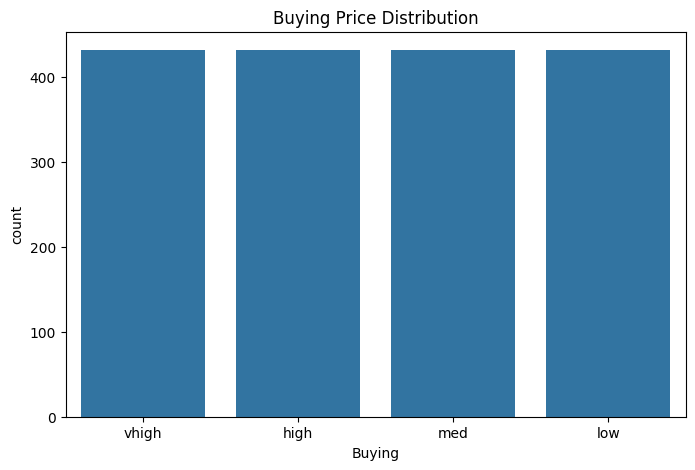

In [37]:
# VISUALIZATION
# HISTOGRAM / COUNTPLOT

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Buying'
)

plt.title('Buying Price Distribution')
plt.show()

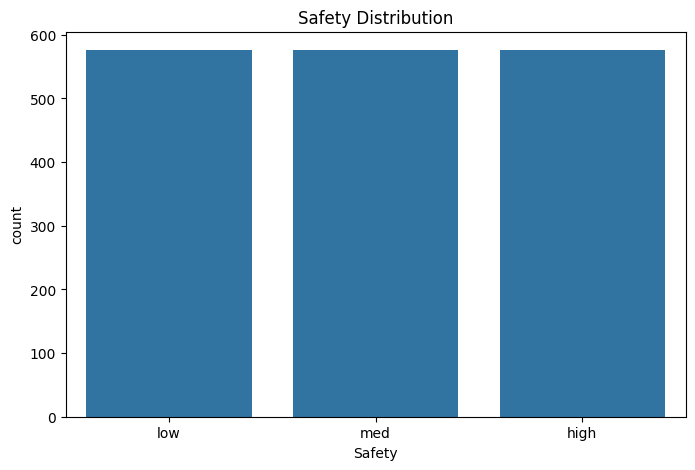

In [38]:
# SAFETY DISTRIBUTION

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Safety'
)

plt.title('Safety Distribution')
plt.show()

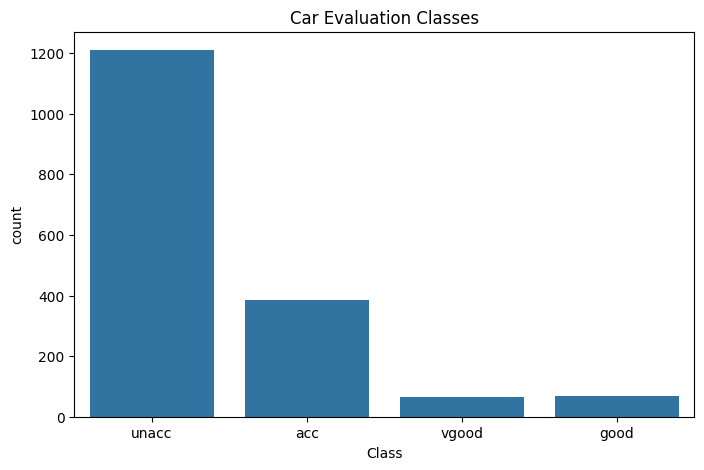

In [39]:
# CLASS DISTRIBUTION

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Class'
)

plt.title('Car Evaluation Classes')
plt.show()

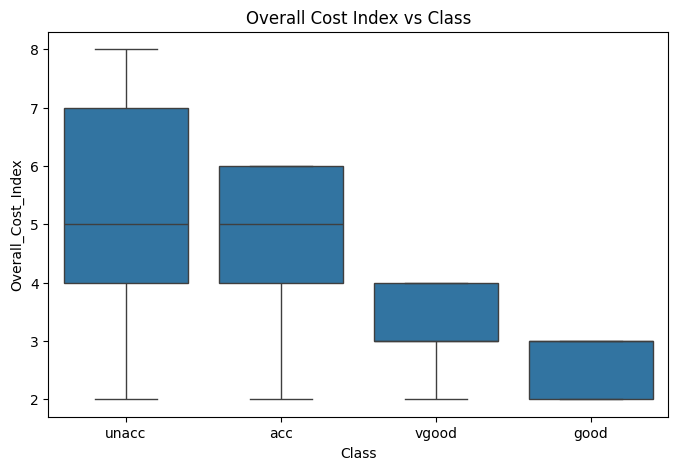

In [40]:
# BOXPLOT

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Class',
    y='Overall_Cost_Index'
)

plt.title('Overall Cost Index vs Class')
plt.show()

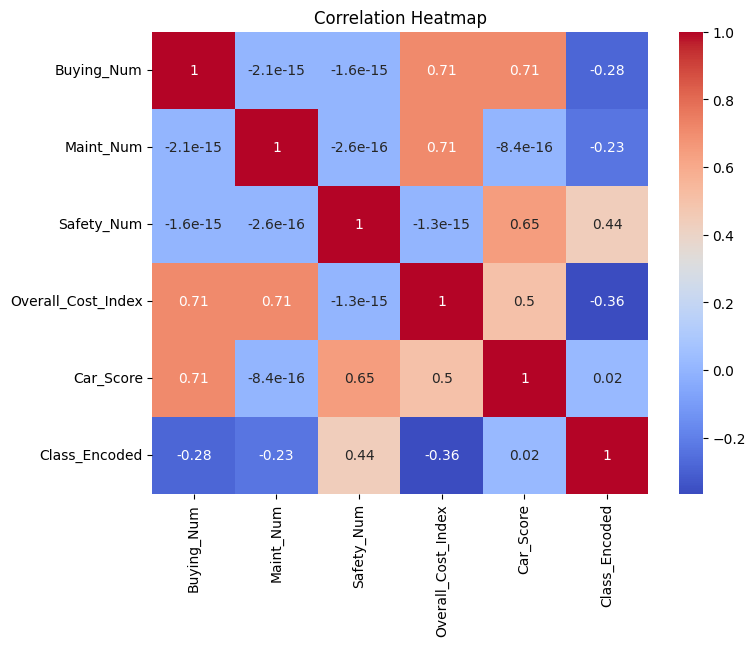

In [41]:
# CORRELATION HEATMAP

corr = df[
    [
        'Buying_Num',
        'Maint_Num',
        'Safety_Num',
        'Overall_Cost_Index',
        'Car_Score',
        'Class_Encoded'
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [42]:
# FEATURE SELECTION USING CORRELATION

target_corr = corr['Class_Encoded'].sort_values(
    ascending=False
)

print(target_corr)

Class_Encoded         1.000000
Safety_Num            0.439337
Car_Score             0.019771
Maint_Num            -0.232422
Buying_Num           -0.282750
Overall_Cost_Index   -0.364282
Name: Class_Encoded, dtype: float64


In [43]:
# NORMALIZATION (MIN-MAX SCALING)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(
    df[
        [
            'Buying_Num',
            'Maint_Num',
            'Safety_Num',
            'Overall_Cost_Index',
            'Car_Score'
        ]
    ]
)

scaled_df = pd.DataFrame(
    scaled_features,
    columns=[
        'Buying_Num',
        'Maint_Num',
        'Safety_Num',
        'Overall_Cost_Index',
        'Car_Score'
    ]
)

display(scaled_df.head())

,Buying_Num,Maint_Num,Safety_Num,Overall_Cost_Index,Car_Score
0,1.0,1.0,0.0,1.0,0.272727
1,1.0,1.0,0.5,1.0,0.636364
2,1.0,1.0,1.0,1.0,1.000000
3,1.0,1.0,0.0,1.0,0.272727
4,1.0,1.0,0.5,1.0,0.636364


In [44]:
# AUTOMATED MISSING VALUE FUNCTION

def handle_missing_values(dataframe):
    for col in dataframe.columns:
        if dataframe[col].dtype == 'object':
            dataframe[col].fillna(
                dataframe[col].mode()[0],
                inplace=True
            )
        else:
            dataframe[col].fillna(
                dataframe[col].median(),
                inplace=True
            )
    return dataframe

print("Function created successfully.")

Function created successfully.


In [45]:
# CONCLUSION

print("Data Wrangling Completed Successfully!")
print("Dataset Shape:", df.shape)

print("\nTasks Completed:")
print("1. Dataset Loading")
print("2. Inspection")
print("3. Missing Value Check")
print("4. Duplicate Removal")
print("5. Data Transformation")
print("6. Feature Engineering")
print("7. Label Encoding")
print("8. One-Hot Encoding")
print("9. Aggregation & Grouping")
print("10. Data Visualization")
print("11. Normalization")
print("12. Feature Selection")

Data Wrangling Completed Successfully!
Dataset Shape: (1728, 15)

Tasks Completed:
1. Dataset Loading
2. Inspection
3. Missing Value Check
4. Duplicate Removal
5. Data Transformation
6. Feature Engineering
7. Label Encoding
8. One-Hot Encoding
9. Aggregation & Grouping
10. Data Visualization
11. Normalization
12. Feature Selection
